## 1. Project Objective
### The objective of this project is to build an AI-powered technical support assistant capable of ticket classification, sentiment analysis, escalation prediction, and KPI analytics using customer support ticket data.

## 2. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

In [2]:
df=pd.read_csv(r"C:\Users\VAIBHAV\Downloads\customer_support_tickets.csv\customer_support_tickets.csv")

## 4. Dataset Overview


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

## 5. Missing Value Analysis


In [4]:
df['Resolution'].fillna('Pending Resolution', inplace=True)

C:\Users\VAIBHAV\AppData\Local\Temp\ipykernel_19092\3188084531.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Resolution'].fillna('Pending Resolution', inplace=True)


In [5]:
df['First Response Time'].isnull().sum()

np.int64(2819)

In [6]:
df['Customer Satisfaction Rating'] = df['Customer Satisfaction Rating'].fillna('Not Rated')

In [7]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                         0
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating       0
dtype: int64

In [8]:
df['Ticket Status'].value_counts()

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

In [9]:
df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [10]:
df.groupby('Ticket Status')[[
    'Resolution',
    'First Response Time',
    'Time to Resolution',
    'Customer Satisfaction Rating'
]].apply(lambda x: x.isnull().sum())

,Resolution,First Response Time,Time to Resolution,Customer Satisfaction Rating
Ticket Status,,,,
Closed,0,0,0,0
Open,0,2819,2819,0
Pending Customer Response,0,0,2881,0


In [11]:
df['Ticket Type'].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [12]:
df['Ticket Priority'].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [13]:
df['Ticket Channel'].value_counts()

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

In [14]:
df['combined_text'] = (
    df['Ticket Subject'] + ' ' +
    df['Ticket Description']
)

## The combined_text feature merges ticket subject and ticket description to create a richer NLP input for downstream classification and sentiment analysis tasks.

In [15]:
df['combined_text'].head()

0    Product setup I'm having an issue with the {pr...
1    Peripheral compatibility I'm having an issue w...
2    Network problem I'm facing a problem with my {...
3    Account access I'm having an issue with the {p...
4    Data loss I'm having an issue with the {produc...
Name: combined_text, dtype: object

## Initial Insights
- Closed tickets contain complete workflow information including resolution metrics.
- Open tickets are associated with missing response and resolution values.
- Ticket lifecycle states strongly influence missing value patterns.
- Dataset supports both NLP workflows and operational KPI analytics.

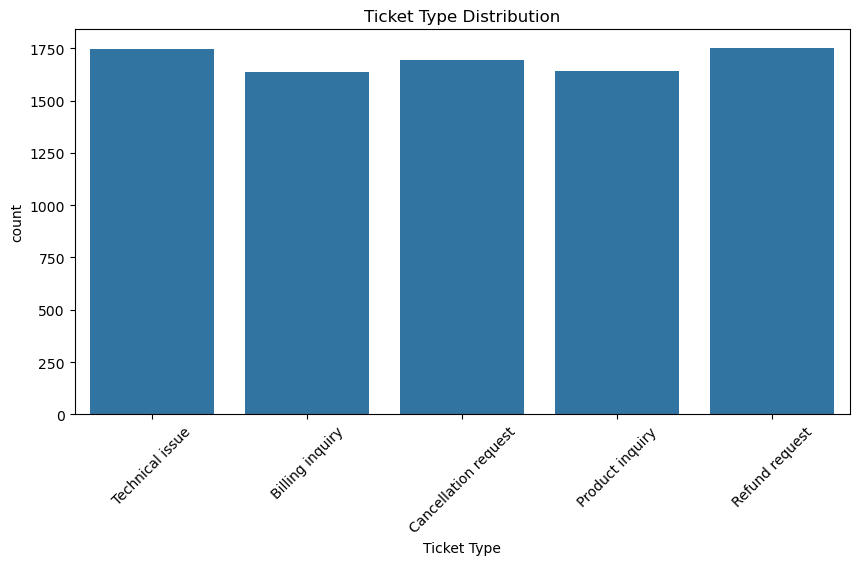

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Ticket Type')
plt.xticks(rotation=45)
plt.title('Ticket Type Distribution')
plt.show()

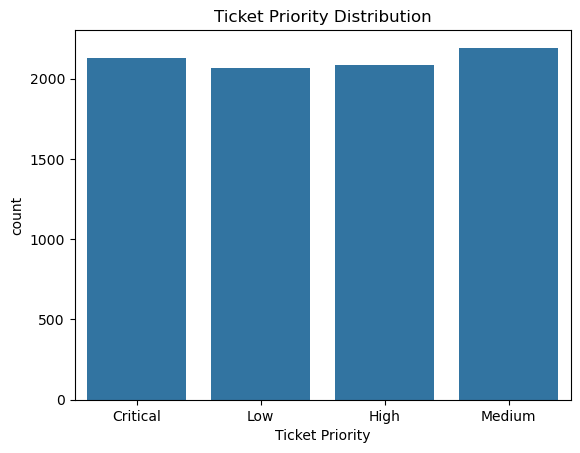

In [17]:
sns.countplot(data=df, x='Ticket Priority')
plt.title('Ticket Priority Distribution')
plt.show()

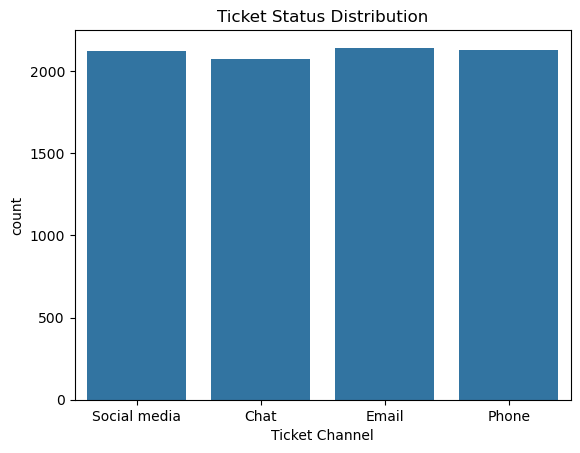

In [22]:
sns.countplot(data=df, x='Ticket Channel')
plt.title('Ticket Status Distribution')
plt.show()

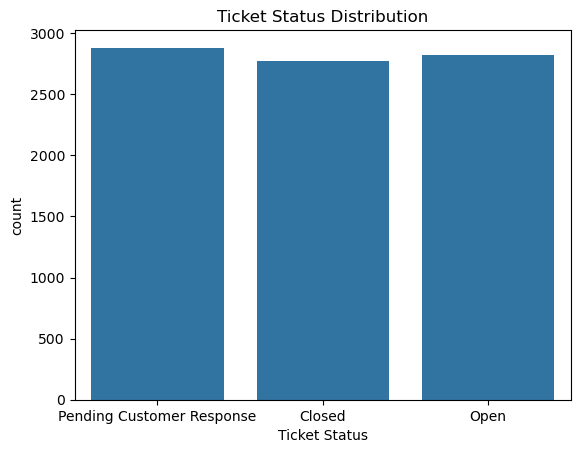

In [18]:
sns.countplot(data=df, x='Ticket Status')
plt.title('Ticket Status Distribution')
plt.show()

In [21]:
df['combined_text'].head()

0    Product setup I'm having an issue with the {pr...
1    Peripheral compatibility I'm having an issue w...
2    Network problem I'm facing a problem with my {...
3    Account access I'm having an issue with the {p...
4    Data loss I'm having an issue with the {produc...
Name: combined_text, dtype: object

### Text Cleaning & NLP Preparation

###  setting text to lowercase to standardize the text data for NLP processing

In [23]:
df['combined_text'] = df['combined_text'].str.lower()

In [24]:
import re

## Removed punctuations
To improve:

classification quality,
vectorization,
sentiment analysis

In [25]:
df['combined_text'] = df['combined_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x)
)

### Remove noisy words like, the,is, and

In [26]:
import nltk
from nltk.corpus import stopwords

In [28]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VAIBHAV\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [29]:
stop_words = set(stopwords.words('english'))

In [30]:
df['combined_text'] = df['combined_text'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [31]:
df['combined_text'].head()

0    product setup im issue productpurchased please...
1    peripheral compatibility im issue productpurch...
2    network problem im facing problem productpurch...
3    account access im issue productpurchased pleas...
4    data loss im issue productpurchased please ass...
Name: combined_text, dtype: object

### -we can add more unwanted words later if we discover any in future

In [33]:
unwanted_terms = [
    'productpurchased'
]

for term in unwanted_terms:
    df['combined_text'] = df['combined_text'].str.replace(term, '', regex=False)

In [34]:
df['combined_text'].head(10)

0    product setup im issue  please assist billing ...
1    peripheral compatibility im issue  please assi...
2    network problem im facing problem   turning wo...
3    account access im issue  please assist problem...
4    data loss im issue  please assist note seller ...
5    payment issue im facing problem   turning work...
6    refund request im unable access  account keeps...
7    battery life im issue  please assist thanks co...
8    installation support im issue  please assist t...
9    payment issue  making strange noises functioni...
Name: combined_text, dtype: object

### Creating a new dataset for model training

In [35]:
model_df = df[[
    'combined_text',
    'Ticket Type',
    'Ticket Priority',
    'Ticket Status'
]]

In [36]:
model_df.head()

,combined_text,Ticket Type,Ticket Priority,Ticket Status
0,product setup im issue please assist billing ...,Technical issue,Critical,Pending Customer Response
1,peripheral compatibility im issue please assi...,Technical issue,Critical,Pending Customer Response
2,network problem im facing problem turning wo...,Technical issue,Low,Closed
3,account access im issue please assist problem...,Billing inquiry,Low,Closed
4,data loss im issue please assist note seller ...,Billing inquiry,Low,Closed


In [37]:
model_df.isnull().sum()

combined_text      0
Ticket Type        0
Ticket Priority    0
Ticket Status      0
dtype: int64

### Model training

In [38]:
from sklearn.model_selection import train_test_split

X = model_df['combined_text']
y = model_df['Ticket Type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Why TF-IDF?

It helps identify:

important words
meaningful ticket keywords
category-specific terms

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [41]:
y_pred = model.predict(X_test_tfidf)

In [42]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.1859504132231405
                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.13      0.15       357
Cancellation request       0.18      0.18      0.18       327
     Product inquiry       0.18      0.17      0.18       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.20      0.23      0.22       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.18      1694
        weighted avg       0.18      0.19      0.18      1694



In [43]:
df[['Ticket Type', 'combined_text']].sample(15)

,Ticket Type,combined_text
3981,Technical issue,payment issue im issue please assist 152737sa...
7009,Billing inquiry,delivery problem im facing issues logging acc...
680,Billing inquiry,cancellation request im issue please assist t...
1439,Product inquiry,battery life im issue please assist iphone on...
2364,Refund request,product compatibility im issue please assist ...
8291,Refund request,product setup im issue please assist believe ...
4709,Cancellation request,product setup im issue please assist way fix ...
2951,Cancellation request,data loss im issue please assist please read ...
4687,Billing inquiry,product compatibility im issue please assist ...
1954,Billing inquiry,product recommendation im issue please assist...


## Model Evaluation Insights

Initial ticket classification performance was low due to inconsistent ticket labeling and template-generated support text. Multiple tickets contained issue descriptions that did not align with their assigned ticket categories.

Based on this observation, the project architecture was adjusted to focus on keyword-based knowledge base retrieval and support workflow automation instead of relying solely on supervised classification.

In [47]:
model_df.to_csv('model_ready_support_tickets.csv', index=False)